# COGS 109 — Final Project Workbook
## Predicting Depression Risk from Lifestyle and Workplace Factors

**Team members:** Veeratat K., Valerie Robles

**Date:** 5/27/2026 
---

---
# Setup & Imports

**Steps:**
- [x] Import all libraries you think you will need (numpy, pandas, matplotlib, sklearn, etc.)
- [x] Set a random seed for reproducibility
- [x] Print a confirmation message so you know everything imported correctly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report


# Setting up Randomseed

In [3]:
# setting up randomseed for cross-validation fold splits
# so anytime when each of the members run the code, we will all get the same output/result.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

---
# Load & Explore the Data

## Datasets
### 1st Dataset: Professional
- https://www.kaggle.com/datasets/ikynahidwin/depression-professional-dataset/data
### 2nd Dataset: Student
- https://www.kaggle.com/datasets/hopesb/student-depression-dataset?utm_source=chatgpt.com

### Load 1st Dataset:

In [4]:
# Step: Load the data
# Dataset: 1
# Depression-professional-dataset
path_1 = "Depression_Professional_Dataset.csv"
if os.path.exists(path_1):
    df_prof = pd.read_csv(path_1)  
    print('Dataset shape:', df_prof.shape)
    display(df_prof.head(10))
else:
    print(f"Error: File not found at {path_1}.")

Dataset shape: (2054, 11)


,Gender,Age,Work Pressure,Job Satisfaction,Sleep Duration,Dietary Habits,Have you ever had suicidal thoughts ?,Work Hours,Financial Stress,Family History of Mental Illness,Depression
0,Female,37,2.0,4.0,7-8 hours,Moderate,No,6,2,No,No
1,Male,60,4.0,3.0,5-6 hours,Unhealthy,Yes,0,4,Yes,No
2,Female,42,2.0,3.0,5-6 hours,Moderate,No,0,2,No,No
3,Female,44,3.0,5.0,7-8 hours,Healthy,Yes,1,2,Yes,No
4,Male,48,4.0,3.0,7-8 hours,Moderate,Yes,6,5,Yes,No
5,Female,60,1.0,4.0,7-8 hours,Unhealthy,Yes,12,3,Yes,No
6,Female,30,4.0,2.0,More than 8 hours,Healthy,No,3,1,No,No
7,Male,30,1.0,2.0,More than 8 hours,Unhealthy,Yes,6,1,No,No
8,Male,56,1.0,2.0,More than 8 hours,Moderate,Yes,11,5,Yes,No
9,Female,35,3.0,4.0,Less than 5 hours,Moderate,No,6,4,Yes,No


### Check column names, data types, and any missing values in dataset 1

In [5]:
df_prof.info()
df_prof.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2054 entries, 0 to 2053
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Gender                                 2054 non-null   object 
 1   Age                                    2054 non-null   int64  
 2   Work Pressure                          2054 non-null   float64
 3   Job Satisfaction                       2054 non-null   float64
 4   Sleep Duration                         2054 non-null   object 
 5   Dietary Habits                         2054 non-null   object 
 6   Have you ever had suicidal thoughts ?  2054 non-null   object 
 7   Work Hours                             2054 non-null   int64  
 8   Financial Stress                       2054 non-null   int64  
 9   Family History of Mental Illness       2054 non-null   object 
 10  Depression                             2054 non-null   object 
dtypes: f

Gender                                   0
Age                                      0
Work Pressure                            0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Have you ever had suicidal thoughts ?    0
Work Hours                               0
Financial Stress                         0
Family History of Mental Illness         0
Depression                               0
dtype: int64

## Load 2st Dataset:

In [6]:
#Loading data
path_2 = "Student_Depression_Dataset.csv"
if os.path.exists(path_2):
    df_student = pd.read_csv(path_2)  
    print('Dataset shape:', df_student.shape)
    display(df_student.head(10))
else:
    print(f"Error: File not found at {path_2}.")

Dataset shape: (27901, 18)


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,Less than 5 hours,Healthy,PhD,No,4.0,1.0,No,0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,7-8 hours,Healthy,BSc,No,1.0,2.0,No,0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,Less than 5 hours,Unhealthy,Class 12,No,0.0,1.0,Yes,0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,7-8 hours,Moderate,B.Ed,Yes,12.0,3.0,No,1
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,Less than 5 hours,Moderate,LLB,Yes,2.0,5.0,No,1


### Check column names, data types, and any missing values in Dataset 2

In [7]:
df_student.info()
df_student.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  Di

id                                       0
Gender                                   0
Age                                      0
City                                     0
Profession                               0
Academic Pressure                        0
Work Pressure                            0
CGPA                                     0
Study Satisfaction                       0
Job Satisfaction                         0
Sleep Duration                           0
Dietary Habits                           0
Degree                                   0
Have you ever had suicidal thoughts ?    0
Work/Study Hours                         0
Financial Stress                         3
Family History of Mental Illness         0
Depression                               0
dtype: int64

In [8]:
df_student = df_student.dropna(subset=['Financial Stress'])
print("Rows after dropping:", len(df_student))

Rows after dropping: 27898


In [9]:
# Explore dataset columns
prof_col = df_prof.columns
print("Professor Depression Columns",prof_col)
student_col = df_student.columns
print("Student Depression Columns",student_col)

Professor Depression Columns Index(['Gender', 'Age', 'Work Pressure', 'Job Satisfaction', 'Sleep Duration',
       'Dietary Habits', 'Have you ever had suicidal thoughts ?', 'Work Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')
Student Depression Columns Index(['id', 'Gender', 'Age', 'City', 'Profession', 'Academic Pressure',
       'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction',
       'Sleep Duration', 'Dietary Habits', 'Degree',
       'Have you ever had suicidal thoughts ?', 'Work/Study Hours',
       'Financial Stress', 'Family History of Mental Illness', 'Depression'],
      dtype='object')


In [10]:
print('--Professor--')
display(df_prof["Depression"].value_counts())
print('--Student--')
df_student["Depression"].value_counts()

--Professor--


Depression
No     1851
Yes     203
Name: count, dtype: int64

--Student--


Depression
1    16335
0    11563
Name: count, dtype: int64

In [11]:
# Check unique values in both datasets BEFORE merge
print("Student Depression unique values:")
print(df_student['Depression'].unique())

print("\nProfessional Depression unique values:")
print(df_prof['Depression'].unique())

Student Depression unique values:
[1 0]

Professional Depression unique values:
['No' 'Yes']


---
## Cleanup & Merge dataset

In [12]:
df_prof_cleanup = pd.DataFrame({
    'Gender': df_prof['Gender'],
    'Age': df_prof['Age'],
    'Work_or_Academic_Pressure' : df_prof['Work Pressure'],
    'Job_or_Study_Satisfaction' : df_prof['Job Satisfaction'],
    'Sleep_Duration' : df_prof['Sleep Duration'],
    'Dietary_Habits' : df_prof['Dietary Habits'],
    'Suicidal_Thoughts' : df_prof['Have you ever had suicidal thoughts ?'],
    'Work_or_Study_Hours' : df_prof['Work Hours'],
    'Financial_Stress' : df_prof['Financial Stress'],
    'Family_History_of_Mental_Illness' : df_prof['Family History of Mental Illness'],
    'Depression' : df_prof['Depression'],
    'Source' : 'Professional'
})
print('--Professor--')
display(df_prof_cleanup.head())

df_student_cleanup = pd.DataFrame({
    'Gender': df_student['Gender'],
    'Age': df_student['Age'],
    'Work_or_Academic_Pressure' : df_student['Work Pressure'],
    'Job_or_Study_Satisfaction' : df_student['Job Satisfaction'],
    'Sleep_Duration' : df_student['Sleep Duration'],
    'Dietary_Habits' : df_student['Dietary Habits'],
    'Suicidal_Thoughts' : df_student['Have you ever had suicidal thoughts ?'],
    'Work_or_Study_Hours' : df_student['Work/Study Hours'],
    'Financial_Stress' : df_student['Financial Stress'],
    'Family_History_of_Mental_Illness' : df_student['Family History of Mental Illness'],
    'Depression' : df_student['Depression'],
    'Source' : 'Student'
})
print('--Student--')
display(df_student_cleanup.head())

# Fix professional depression BEFORE merge
df_prof_cleanup['Depression'] = df_prof_cleanup['Depression'].map({'Yes': 1, 'No': 0}).astype(int)

# Verify
print("Professional Depression unique values after fix:")
print(df_prof_cleanup['Depression'].unique())
# should show [0, 1]

# Merging
df_merg_pro_stu = pd.concat([df_prof_cleanup, df_student_cleanup], ignore_index=True)
print("Merged 2 dataset:", df_merg_pro_stu.shape)
print("Observations: n =",df_merg_pro_stu.shape[0])
print("Predictor: p =",df_merg_pro_stu.shape[1]-2) # Excluding "Depression" and "Source"

# "Depression" is (y) or "target variable"
# "Source" is "naming the colume"
# For write up
# professor (2054,11)
# student (27898,18); after dropping 3 nulls value
# n(Observations) = 29952, p(Predictor) = 10

--Professor--


,Gender,Age,Work_or_Academic_Pressure,Job_or_Study_Satisfaction,Sleep_Duration,Dietary_Habits,Suicidal_Thoughts,Work_or_Study_Hours,Financial_Stress,Family_History_of_Mental_Illness,Depression,Source
0,Female,37,2.0,4.0,7-8 hours,Moderate,No,6,2,No,No,Professional
1,Male,60,4.0,3.0,5-6 hours,Unhealthy,Yes,0,4,Yes,No,Professional
2,Female,42,2.0,3.0,5-6 hours,Moderate,No,0,2,No,No,Professional
3,Female,44,3.0,5.0,7-8 hours,Healthy,Yes,1,2,Yes,No,Professional
4,Male,48,4.0,3.0,7-8 hours,Moderate,Yes,6,5,Yes,No,Professional


--Student--


,Gender,Age,Work_or_Academic_Pressure,Job_or_Study_Satisfaction,Sleep_Duration,Dietary_Habits,Suicidal_Thoughts,Work_or_Study_Hours,Financial_Stress,Family_History_of_Mental_Illness,Depression,Source
0,Male,33.0,0.0,0.0,5-6 hours,Healthy,Yes,3.0,1.0,No,1,Student
1,Female,24.0,0.0,0.0,5-6 hours,Moderate,No,3.0,2.0,Yes,0,Student
2,Male,31.0,0.0,0.0,Less than 5 hours,Healthy,No,9.0,1.0,Yes,0,Student
3,Female,28.0,0.0,0.0,7-8 hours,Moderate,Yes,4.0,5.0,Yes,1,Student
4,Female,25.0,0.0,0.0,5-6 hours,Moderate,Yes,1.0,1.0,No,0,Student


Professional Depression unique values after fix:
[0 1]
Merged 2 dataset: (29952, 12)
Observations: n = 29952
Predictor: p = 10


## Check column names, data types, and any missing values in Merge data

In [13]:
print(df_merg_pro_stu.info())
print('------')
print(df_merg_pro_stu.isnull().sum())
print('------')
print(df_merg_pro_stu["Depression"].value_counts())
print('------')
print(df_merg_pro_stu['Source'].value_counts())
print('------')
print(df_merg_pro_stu.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29952 entries, 0 to 29951
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Gender                            29952 non-null  object 
 1   Age                               29952 non-null  float64
 2   Work_or_Academic_Pressure         29952 non-null  float64
 3   Job_or_Study_Satisfaction         29952 non-null  float64
 4   Sleep_Duration                    29952 non-null  object 
 5   Dietary_Habits                    29952 non-null  object 
 6   Suicidal_Thoughts                 29952 non-null  object 
 7   Work_or_Study_Hours               29952 non-null  float64
 8   Financial_Stress                  29952 non-null  float64
 9   Family_History_of_Mental_Illness  29952 non-null  object 
 10  Depression                        29952 non-null  int64  
 11  Source                            29952 non-null  object 
dtypes: f

---
## Plots representing 'Depression' Status before Profession and Student.

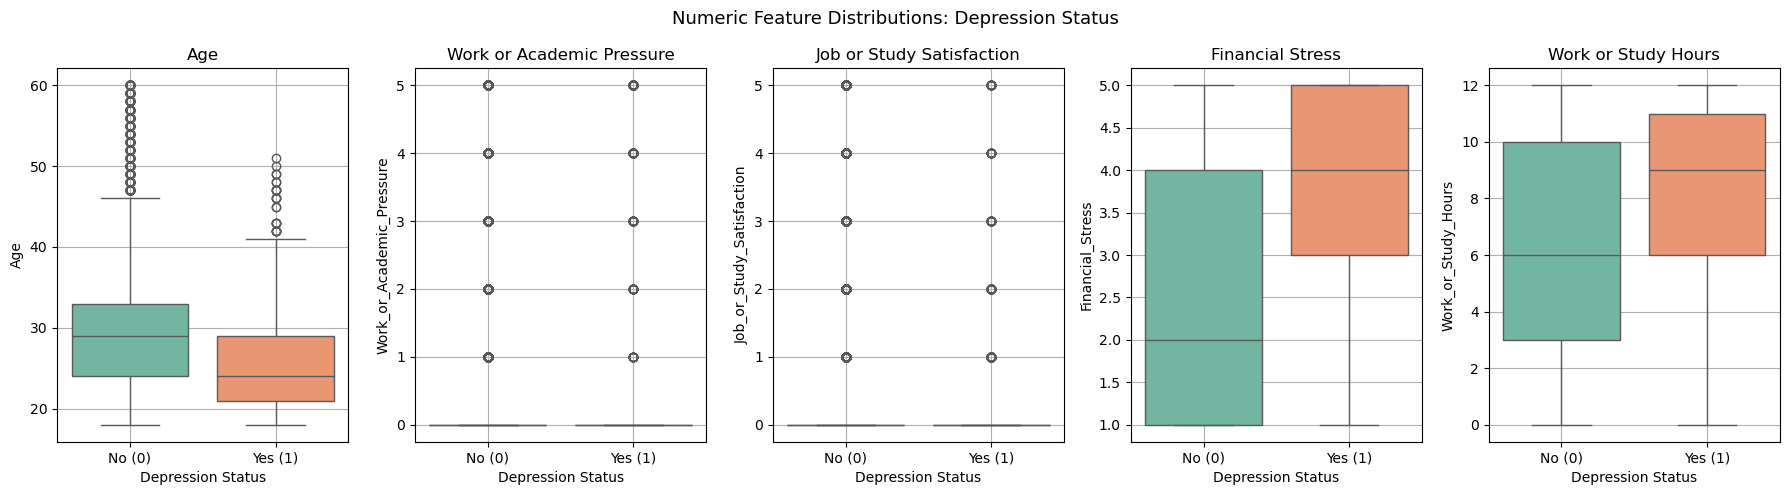

In [14]:
# Plot feature distributions by 'Depression' Status
numeric_features = ['Age', 'Work_or_Academic_Pressure', 'Job_or_Study_Satisfaction', 'Financial_Stress', 'Work_or_Study_Hours']

fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 5))
fig.suptitle('Numeric Feature Distributions: Depression Status', fontsize=13)

for ax, column in zip(axes, numeric_features):
    sns.boxplot(data=df_merg_pro_stu, x='Depression', y=column, ax=ax, hue='Depression', palette='Set2', legend=False)
    ax.set_title(column.replace('_', ' '))
    ax.set_xlabel('Depression Status')
    ax.set_xticks([0, 1])                        
    ax.set_xticklabels(['No (0)', 'Yes (1)'])    
    ax.grid(True)

plt.tight_layout()
plt.show()

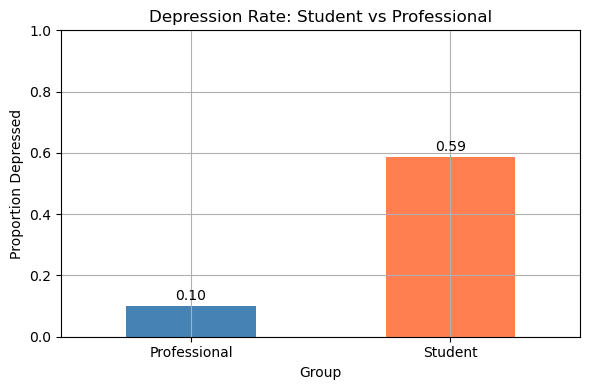

In [16]:
# depression rate by Student vs Professional
fig, ax = plt.subplots(figsize=(6, 4))

depression_rates = df_merg_pro_stu.groupby('Source')['Depression'].mean()

depression_rates.plot(kind='bar', ax=ax,color=['steelblue', 'coral'])

ax.set_title('Depression Rate: Student vs Professional')
ax.set_ylabel('Proportion Depressed')
ax.set_xlabel('Group')
ax.set_xticklabels(['Professional', 'Student'], rotation=0)
ax.set_ylim(0, 1)
ax.grid(True)

for i, val in enumerate(depression_rates):
    ax.text(i, val + 0.02, f'{val:.2f}', ha='center')

plt.tight_layout()
plt.show()

---
## Define X and y, Encode & Scale

In [17]:
##Rename
predictors = [
    "Gender",
    "Age",
    "Work_or_Academic_Pressure",
    "Job_or_Study_Satisfaction",
    "Sleep_Duration",
    "Dietary_Habits",
    "Suicidal_Thoughts",
    "Work_or_Study_Hours",
    "Financial_Stress",
    "Family_History_of_Mental_Illness"
]

X = df_merg_pro_stu[predictors]
y = df_merg_pro_stu["Depression"]

#dropping rows
df_clean = pd.concat([X, y], axis=1).dropna()
X = df_clean[predictors]
y = df_clean["Depression"]

print('X shape:',X.shape)
print('Y shape:',y.shape)

# One-hot encode categorical columns
# columns into numbers
X_encoded = pd.get_dummies(X, drop_first=True)
print(X_encoded.columns)
X_encoded.head()

X shape: (29952, 10)
Y shape: (29952,)
Index(['Age', 'Work_or_Academic_Pressure', 'Job_or_Study_Satisfaction',
       'Work_or_Study_Hours', 'Financial_Stress', 'Gender_Male',
       'Sleep_Duration_7-8 hours', 'Sleep_Duration_Less than 5 hours',
       'Sleep_Duration_More than 8 hours', 'Sleep_Duration_Others',
       'Dietary_Habits_Moderate', 'Dietary_Habits_Others',
       'Dietary_Habits_Unhealthy', 'Suicidal_Thoughts_Yes',
       'Family_History_of_Mental_Illness_Yes'],
      dtype='object')


,Age,Work_or_Academic_Pressure,Job_or_Study_Satisfaction,Work_or_Study_Hours,Financial_Stress,Gender_Male,Sleep_Duration_7-8 hours,Sleep_Duration_Less than 5 hours,Sleep_Duration_More than 8 hours,Sleep_Duration_Others,Dietary_Habits_Moderate,Dietary_Habits_Others,Dietary_Habits_Unhealthy,Suicidal_Thoughts_Yes,Family_History_of_Mental_Illness_Yes
0,37.0,2.0,4.0,6.0,2.0,False,True,False,False,False,True,False,False,False,False
1,60.0,4.0,3.0,0.0,4.0,True,False,False,False,False,False,False,True,True,True
2,42.0,2.0,3.0,0.0,2.0,False,False,False,False,False,True,False,False,False,False
3,44.0,3.0,5.0,1.0,2.0,False,True,False,False,False,False,False,False,True,True
4,48.0,4.0,3.0,6.0,5.0,True,True,False,False,False,True,False,False,True,True


In [18]:
#predictors
print("Number of predictors after encoding:", X_encoded.shape[1])
print('p=',X_encoded.shape[1])

Number of predictors after encoding: 15
p= 15


---
## Model 1 - Logistic Regression

In [23]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

demo_predictors = [
    "Gender",
    "Age",
    "Family_History_of_Mental_Illness"
]

X_demo = df_merg_pro_stu[demo_predictors]
y_demo = df_merg_pro_stu["Depression"]

df_demo = pd.concat([X_demo, y_demo], axis=1).dropna()

X_demo = df_demo[demo_predictors]
y_demo = df_demo["Depression"]

X_demo_encoded = pd.get_dummies(X_demo, drop_first=True)

log_demo = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

demo_scores = cross_val_score(
    log_demo,
    X_demo_encoded,
    y_demo,
    cv=kf,
    scoring="accuracy"
)

print("Demographic Model CV Accuracy Scores:",  f"{demo_scores.mean():.3f}", "±", f"{demo_scores.std():.3f}")

Demographic Model CV Accuracy Scores: 0.639 ± 0.002


---
## Model 2 - Full regression model

In [24]:
log_full = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

full_scores = cross_val_score(
    log_full,
    X_encoded,
    y,
    cv=kf,
    scoring="accuracy"
)

print("Full Model CV Accuracy:", f"{full_scores.mean():.3f}", "±", f"{full_scores.std():.3f}")

Full Model CV Accuracy: 0.816 ± 0.003


---
## Model 3 - KNN Comparasion

In [33]:
k_values = [3, 5, 10, 20, 50]
knn_results = []

for k in k_values:
    knn = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )
    scores = cross_val_score(
        knn, 
        X_encoded, 
        y,
        cv=kf, 
        scoring="accuracy"
    )
    knn_results.append({
        "k": k,
        "Mean CV Accuracy": scores.mean(),
        "Std": scores.std()
    })
    
knn_results_df = pd.DataFrame(knn_results)
display(knn_results_df)
best_k = knn_results_df.loc[knn_results_df["Mean CV Accuracy"].idxmax(), "k"]
print(f"Best KNN: k={best_k} with accuracy {knn_results_df['Mean CV Accuracy'].max():.3f}")

,k,Mean CV Accuracy,Std
0,3,0.777711,0.005673
1,5,0.790999,0.005949
2,10,0.798010,0.004808
3,20,0.803853,0.003629
4,50,0.803819,0.003982


Best KNN: k=20 with accuracy 0.804


---
## Model 4 - Comparison Model Table

In [26]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression: Demographic Only",
        "Logistic Regression: Full Model",
        "KNN: k=3",
        "KNN: k=5",
        "KNN: k=10",
        "KNN: k=20",
        "KNN: k=50"
    ],
    "Mean CV Accuracy": [
        demo_scores.mean(),
        full_scores.mean(),
        knn_results_df.loc[knn_results_df["k"] == 3, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 5, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 10, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 20, "Mean CV Accuracy"].values[0],
        knn_results_df.loc[knn_results_df["k"] == 50, "Mean CV Accuracy"].values[0]
    ],
    "Std": [
        demo_scores.std(),
        full_scores.std(),
        knn_results_df.loc[knn_results_df["k"]==3,  "Std"].values[0],
        knn_results_df.loc[knn_results_df["k"]==5,  "Std"].values[0],
        knn_results_df.loc[knn_results_df["k"]==10, "Std"].values[0],
        knn_results_df.loc[knn_results_df["k"]==20, "Std"].values[0],
        knn_results_df.loc[knn_results_df["k"]==50, "Std"].values[0],
    ]
})

model_results

,Model,Mean CV Accuracy,Std
0,Logistic Regression: Demographic Only,0.639056,0.002426
1,Logistic Regression: Full Model,0.816139,0.003069
2,KNN: k=3,0.777711,0.005673
3,KNN: k=5,0.790999,0.005949
4,KNN: k=10,0.798010,0.004808
5,KNN: k=20,0.803853,0.003629
6,KNN: k=50,0.803819,0.003982


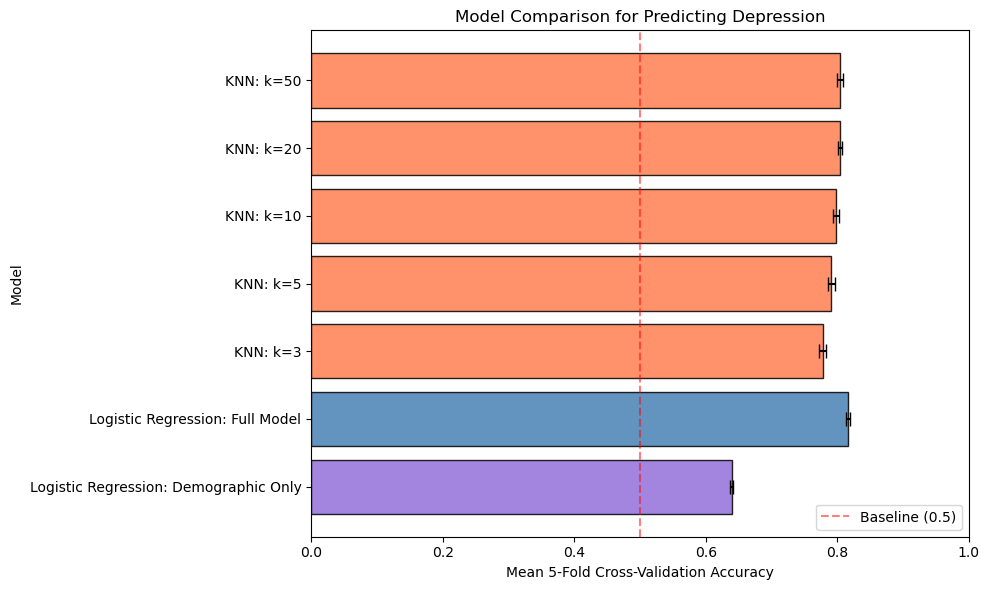

In [27]:
plt.figure(figsize=(10, 6))
bars = plt.barh(
    model_results["Model"],
    model_results["Mean CV Accuracy"],
    xerr=model_results["Std"],
    capsize=5,
    color=['mediumpurple', 'steelblue',
           'coral', 'coral', 'coral', 'coral', 'coral'],
    edgecolor='black', alpha=0.85
)

plt.xlabel("Mean 5-Fold Cross-Validation Accuracy")
plt.ylabel("Model")
plt.title("Model Comparison for Predicting Depression")
plt.xlim(0, 1)
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Baseline (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

---
## Fitting this model

In [28]:
final_model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

final_model.fit(X_encoded, y)
y_pred = final_model.predict(X_encoded)

print("=== Final Model: Full Logistic Regression ===")
print("Training Accuracy :", f"{accuracy_score(y, y_pred):.3f}")
print("Weighted F1 Score ::", f"{f1_score(y, y_pred, average='weighted'):.3f}")
print()
print(classification_report(y, y_pred, target_names=['No Depression', 'Depression']))
print("Final model accuracy on full dataset:", accuracy_score(y, y_pred))

=== Final Model: Full Logistic Regression ===
Training Accuracy : 0.817
Weighted F1 Score :: 0.816

               precision    recall  f1-score   support

No Depression       0.81      0.77      0.79     13414
   Depression       0.82      0.86      0.84     16538

     accuracy                           0.82     29952
    macro avg       0.82      0.81      0.81     29952
 weighted avg       0.82      0.82      0.82     29952

Final model accuracy on full dataset: 0.8165064102564102


---
## Logistic Regression Coefficients

In [29]:
log_reg = final_model.named_steps["logisticregression"]

coefficients = pd.DataFrame({
    "Predictor": X_encoded.columns,
    "Coefficient": log_reg.coef_[0]
})

coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

coefficients_sorted = coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

coefficients_sorted.head(15)

,Predictor,Coefficient,Absolute Coefficient
13,Suicidal_Thoughts_Yes,1.222074,1.222074
0,Age,-0.805863,0.805863
2,Job_or_Study_Satisfaction,-0.783762,0.783762
4,Financial_Stress,0.773452,0.773452
12,Dietary_Habits_Unhealthy,0.510977,0.510977
3,Work_or_Study_Hours,0.447282,0.447282
1,Work_or_Academic_Pressure,0.300035,0.300035
10,Dietary_Habits_Moderate,0.220263,0.220263
7,Sleep_Duration_Less than 5 hours,0.169665,0.169665
14,Family_History_of_Mental_Illness_Yes,0.127663,0.127663


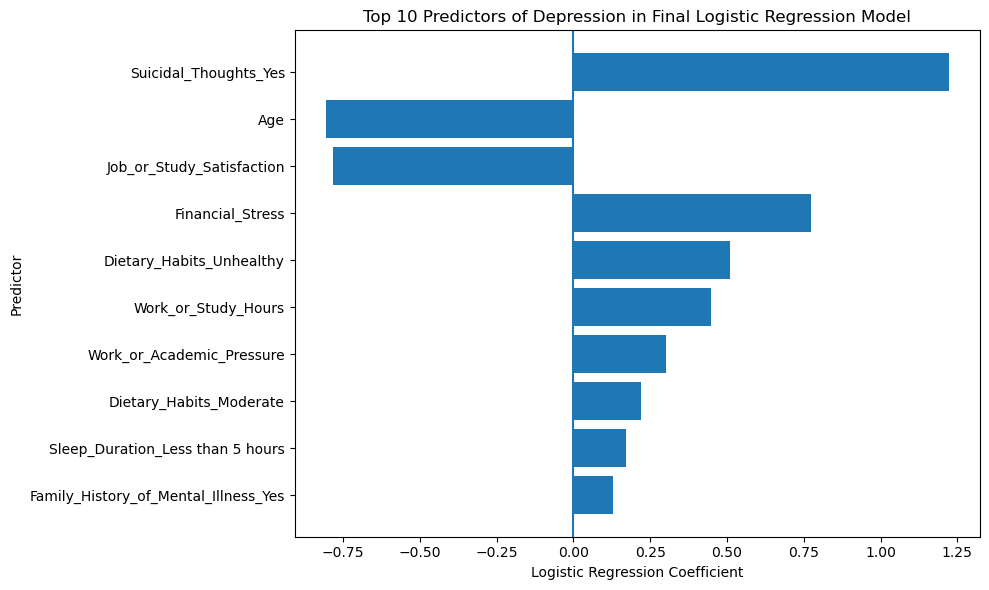

In [30]:
## Final Graph MODEL ESTIMATION
top_coefficients = coefficients_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_coefficients["Predictor"], top_coefficients["Coefficient"])
plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Predictor")
plt.title("Top 10 Predictors of Depression in Final Logistic Regression Model")
plt.axvline(0)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

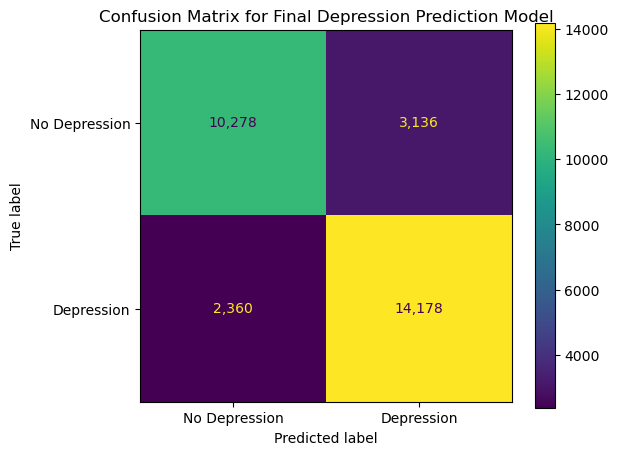

In [35]:
## Confusion Matrix
cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Depression", "Depression"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, values_format='d')
# Display full number
for text in ax.texts:
    text.set_text(f"{int(float(text.get_text())):,}")
plt.title("Confusion Matrix for Final Depression Prediction Model")
#plt.tight_layout()
plt.show()

In [32]:
print("=" * 60)
print("            FINAL RESULTS SUMMARY")
print("=" * 60)
print(model_results.to_string(index=False))
print("=" * 60)
print(f"\nSelected final model : Full Logistic Regression")
print(f"Reason               : Highest CV accuracy, interpretable coefficients")
print(f"Training accuracy    : {accuracy_score(y, y_pred):.3f}")
print(f"Weighted F1 score    : {f1_score(y, y_pred, average='weighted'):.3f}")
print(f"\nHypothesis result:")
print(f"  Demographic-only accuracy : {demo_scores.mean():.3f}")
print(f"  Full model accuracy       : {full_scores.mean():.3f}")
print(f"  → Full model outperforms demographic-only by {(full_scores.mean()-demo_scores.mean()):.3f}")

            FINAL RESULTS SUMMARY
                                Model  Mean CV Accuracy      Std
Logistic Regression: Demographic Only          0.639056 0.002426
      Logistic Regression: Full Model          0.816139 0.003069
                             KNN: k=3          0.777711 0.005673
                             KNN: k=5          0.790999 0.005949
                            KNN: k=10          0.798010 0.004808
                            KNN: k=20          0.803853 0.003629
                            KNN: k=50          0.803819 0.003982

Selected final model : Full Logistic Regression
Reason               : Highest CV accuracy, interpretable coefficients
Training accuracy    : 0.817
Weighted F1 score    : 0.816

Hypothesis result:
  Demographic-only accuracy : 0.639
  Full model accuracy       : 0.816
  → Full model outperforms demographic-only by 0.177
